In [21]:
import pandas as pd

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [23]:
dataset_avis =  pd.read_csv("dataset_avis.csv")
dataset_avis

,comment_id,Commentaire,star,date,client,reponse,source,company,ville,maj,date_commande,ecart,clean_comment,qualité produit,service livraison,service client
0,2,"Vente Lacoste Honteuse , article erroné , arti...",1,2021-06-19 00:00:00+00:00,Vanessa L,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN,"vente lacoste honteuse , article erroné , arti...",1,0,0
1,6,Annulation de commande après 2 mois d ’ attent...,1,2021-06-18 00:00:00+00:00,aurore regnier,"Bonjour Aurore , Je suis sincèrement désolé d'...",TrustPilot,ShowRoom,NaN,NaN,NaN,NaN,annulation de commande après 2 mois d ’ attent...,0,0,1
2,8,Extrêmement deçu pour mes achats lors la vente...,1,2021-06-18 00:00:00+00:00,Ayna,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN,extrêmement deçu pour mes achats lors la vente...,1,0,0
3,9,S'il y'avait une option : ne pas mettre d'étoi...,1,2021-06-18 00:00:00+00:00,linda Ng,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN,s'il y'avait une option : ne pas mettre d'étoi...,1,0,0
4,10,ARNAQUE J ’ ai acheté une combinaison blanche ...,1,2021-06-18 00:00:00+00:00,Sarah,NaN,TrustPilot,ShowRoom,NaN,NaN,NaN,NaN,arnaque j ’ ai acheté une combinaison blanche ...,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6530,15065,Je suis une cliente depuis 10 ans de Vente pri...,4,2015-10-21 00:00:00+00:00,Claudie,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN,je suis une cliente depuis 10 ans de vente pri...,1,0,0
6531,15070,J'ai voulu commandé sur le site plusieurs arti...,1,2015-10-15 00:00:00+00:00,Mr stephane D .,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN,j'ai voulu commandé sur le site plusieurs arti...,1,1,0
6532,15071,J'ai passé 4 fois commande chez eux ces derniè...,3,2015-10-15 00:00:00+00:00,Client,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN,j'ai passé 4 fois commande chez eux ces derniè...,0,1,0
6533,15073,Cliente depuis 2008 sans encombre jusqu ' à ju...,1,2015-10-06 00:00:00+00:00,Bertho,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN,cliente depuis 2008 sans encombre jusqu ' à ju...,1,0,0


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report



In [25]:
X = dataset_avis['clean_comment']  # texte déjà nettoyé
y = dataset_avis[['qualité produit','service livraison','service client']].values  # labels binaires

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from imblearn.over_sampling import SMOTE

# Split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Vectorisation
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

# KNN multilabel
knn = KNeighborsClassifier(
    n_neighbors=10,
    metric="cosine",
    weights="distance"   # recommandé pour du texte
)

clf = OneVsRestClassifier(knn)
clf.fit(X_train, y_train)

# Prédictions
y_pred = clf.predict(X_test)
y_pred

array([[1, 1, 0],
       [0, 0, 0],
       [1, 0, 0],
       ...,
       [0, 0, 1],
       [1, 1, 0],
       [0, 1, 0]], shape=(1307, 3))

In [27]:
from sklearn.metrics import confusion_matrix
import pandas as pd

label_names = ['qualité produit','service livraison','service client']  # adapte à ton cas

for i, label in enumerate(label_names):
    cm = confusion_matrix(y_test[:, i], y_pred[:, i])
    cm_df = pd.DataFrame(
        cm,
        index=['Vrai 0', 'Vrai 1'],
        columns=['Prédit 0', 'Prédit 1']
    )
    
    print(f"\nMatrice de confusion pour {label}")
    print(cm_df)



Matrice de confusion pour qualité produit
        Prédit 0  Prédit 1
Vrai 0       359       231
Vrai 1       126       591

Matrice de confusion pour service livraison
        Prédit 0  Prédit 1
Vrai 0       588       172
Vrai 1       168       379

Matrice de confusion pour service client
        Prédit 0  Prédit 1
Vrai 0      1049        49
Vrai 1       157        52


In [28]:
# for i, label in enumerate(label_names):
#     cm = confusion_matrix(
#         y_test[:, i],
#         y_pred[:, i],
#         labels=[0, 1]
#     )

#     cm_df = pd.DataFrame(
#         cm,
#         index=['Vrai 0', 'Vrai 1'],
#         columns=['Prédit 0', 'Prédit 1']
#     )

#     print(f"\nMatrice de confusion pour {label}")
#     print(cm_df)


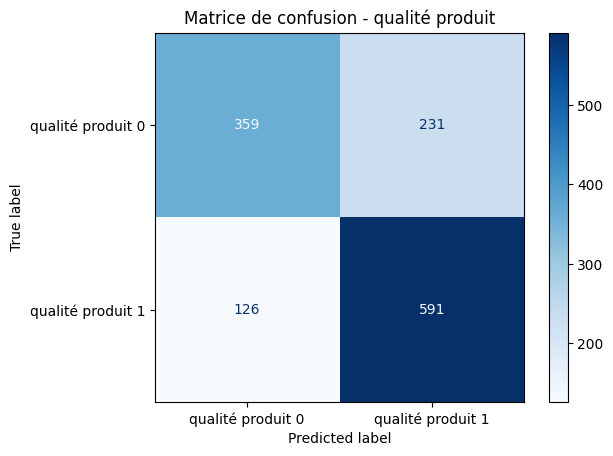

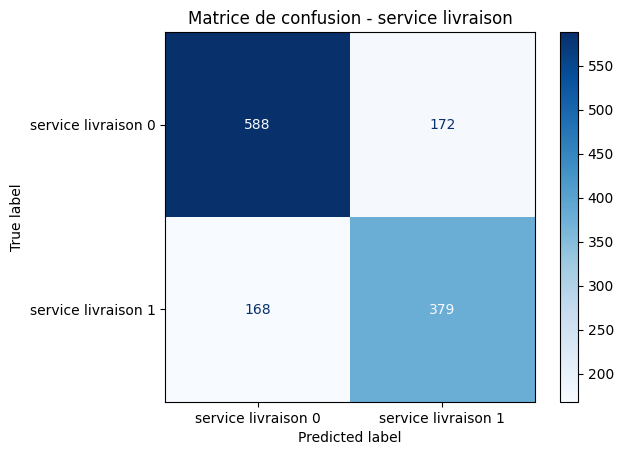

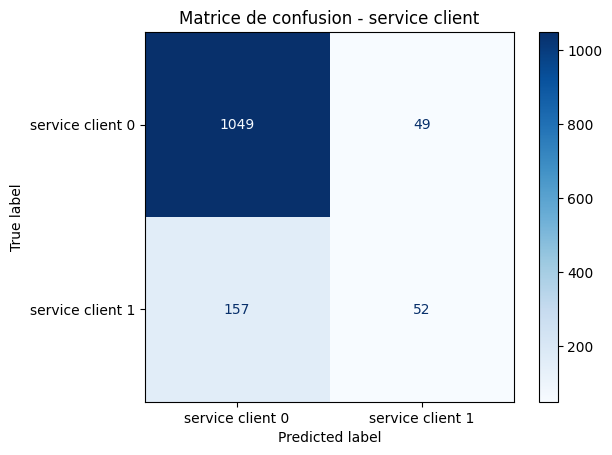

In [29]:
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Calcul des matrices de confusion par label
mcm = multilabel_confusion_matrix(y_test, y_pred)

# Affichage avec ConfusionMatrixDisplay
for i, label in enumerate(label_names):
    disp = ConfusionMatrixDisplay(confusion_matrix=mcm[i],
                                  display_labels=[f'{label} 0', f'{label} 1'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matrice de confusion - {label}")
    plt.show()

In [30]:
# Classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=label_names,
    zero_division=0  # évite les warnings si un label n'est pas prédit
)

print(report)

                   precision    recall  f1-score   support

  qualité produit       0.72      0.82      0.77       717
service livraison       0.69      0.69      0.69       547
   service client       0.51      0.25      0.34       209

        micro avg       0.69      0.69      0.69      1473
        macro avg       0.64      0.59      0.60      1473
     weighted avg       0.68      0.69      0.68      1473
      samples avg       0.70      0.71      0.69      1473



In [31]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', OneVsRestClassifier(
        KNeighborsClassifier(
            n_neighbors=10,
            metric='cosine'
        )
    ))
])


In [32]:
from sklearn.metrics import make_scorer, hamming_loss

hamming_scorer = make_scorer(
    hamming_loss,
    greater_is_better=False
)


In [33]:
from sklearn.metrics import make_scorer, hamming_loss

hamming_scorer = make_scorer(
    hamming_loss,
    greater_is_better=False
)


In [34]:
from sklearn.model_selection import cross_validate

scoring = {
    'f1_micro': 'f1_micro',
    'f1_macro': 'f1_macro',
    'hamming_loss': hamming_scorer   # ✅ PAS hamming_loss
}

cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)


In [35]:
import numpy as np

print("F1 micro :", np.mean(cv_results['test_f1_micro']))
print("F1 macro :", np.mean(cv_results['test_f1_macro']))
print("Hamming loss :", -np.mean(cv_results['test_hamming_loss']))


F1 micro : 0.665961038172731
F1 macro : 0.5140748943470075
Hamming loss : 0.2415710277990309


In [36]:
dataset_avis =  pd.read_csv("100_avis_annote.csv", sep=';')
dataset_avis

,comment_id,Commentaire,star,date,client,reponse,source,company,ville,maj,date_commande,ecart,clean_comment,qualité produit,service livraison,service client
0,9720,Très bonne expérience . Ras,5,28/06/2020,NaN,NaN,TrustedShop,ShowRoom,NaN,NaN,NaN,NaN,très bonne expérience . ras,0,0,0
1,8772,Bonjour je n ai toujours pas reçu ma commande,1,06/07/2020,NaN,NaN,TrustedShop,ShowRoom,NaN,NaN,NaN,NaN,bonjour je n ai toujours pas reçu ma commande,0,1,0
2,11565,Commender au mois de mai reçu au mois de juin ...,3,13/06/2020,NaN,NaN,TrustedShop,ShowRoom,NaN,NaN,NaN,NaN,commender au mois de mai reçu au mois de juin ...,0,1,0
3,4115,Très satisfaite de ma commande,5,14/11/2020,Véronique H .,"Bonjour , Merci pour votre gentil message , no...",TrustedShop,ShowRoom,BUCHELAY,NaN,02/11/2020,12.0,très satisfaite de ma commande,0,0,0
4,6363,Tout s'est très bien passé,5,07/08/2020,Mireille C .,NaN,TrustedShop,ShowRoom,Manosque,NaN,NaN,NaN,tout s'est très bien passé,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,12336,Ils ne respectent même pas leurs clients fidèl...,1,2021-04-21 00:00:00+00:00,Nafi Erdogan,NaN,TrustPilot,VeePee,NaN,NaN,NaN,NaN,ils ne respectent même pas leurs clients fidèl...,0,0,1
96,2683,Achat satisfaisant Envoi rapide,4,15/04/2021,NaN,"Bonjour , Merci infiniment pour votre apprécia...",TrustedShop,ShowRoom,NaN,NaN,08/04/2021,7.0,achat satisfaisant envoi rapide,0,1,0
97,11593,Je ne l'ai pas reçu je suis déçu car c'est un ...,1,13/06/2020,NaN,NaN,TrustedShop,ShowRoom,NaN,NaN,NaN,NaN,je ne l'ai pas reçu je suis déçu car c'est un ...,0,1,0
98,11657,Super pour ma part pour cette commande,5,12/06/2020,NaN,NaN,TrustedShop,ShowRoom,NaN,NaN,NaN,NaN,super pour ma part pour cette commande,0,0,0


In [37]:
X_annot = dataset_avis['clean_comment']  # texte déjà nettoyé
y_annot = dataset_avis[['qualité produit','service livraison','service client']].values  # labels binaires

In [38]:
from sklearn.model_selection import cross_val_predict
from sklearn.multioutput import MultiOutputClassifier

# Vectorisation
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_annot)

clf = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=5))
y_pred = cross_val_predict(clf, X_train, y_annot, cv=5)


In [39]:
from sklearn.metrics import confusion_matrix
import pandas as pd

label_names = ['qualité produit','service livraison','service client']  # adapte à ton cas

for i, label in enumerate(label_names):
    cm = confusion_matrix(y_annot[:, i], y_pred[:, i])
    cm_df = pd.DataFrame(
        cm,
        index=['Vrai 0', 'Vrai 1'],
        columns=['Prédit 0', 'Prédit 1']
    )
    
    print(f"\nMatrice de confusion pour {label}")
    print(cm_df)


Matrice de confusion pour qualité produit
        Prédit 0  Prédit 1
Vrai 0        43        16
Vrai 1        16        25

Matrice de confusion pour service livraison
        Prédit 0  Prédit 1
Vrai 0        72         7
Vrai 1        20         1

Matrice de confusion pour service client
        Prédit 0  Prédit 1
Vrai 0        56        17
Vrai 1        13        14


In [40]:
# Classification report
report = classification_report(
    y_annot,
    y_pred,
    target_names=label_names,
    zero_division=0  # évite les warnings si un label n'est pas prédit
)

print(report)

                   precision    recall  f1-score   support

  qualité produit       0.61      0.61      0.61        41
service livraison       0.12      0.05      0.07        21
   service client       0.45      0.52      0.48        27

        micro avg       0.50      0.45      0.47        89
        macro avg       0.40      0.39      0.39        89
     weighted avg       0.45      0.45      0.44        89
      samples avg       0.33      0.32      0.31        89



# Ignore saved models
models/
*.pkl
*.h5
*.pt